<a href="https://colab.research.google.com/github/adityastark10/PRODIGY_ML_03/blob/main/SVM_classification_Cats%26Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q scikit-image scikit-learn

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [6]:
!pip install -q kagglehub

In [7]:
import kagglehub

path = kagglehub.dataset_download(
    "shaunthesheep/microsoft-catsvsdogs-dataset"
)

print("Dataset downloaded to:")
print(path)

100%|██████████| 788M/788M [00:07<00:00, 104MB/s] 

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1


In [11]:
import os

print(os.listdir(path))

['MSR-LA - 3467.docx', 'readme[1].txt', 'PetImages']


In [12]:
dataset_path = os.path.join(path, "PetImages")

cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

print("Cat path:", cat_path)
print("Dog path:", dog_path)

Cat path: /root/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Cat
Dog path: /root/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Dog


In [13]:
print("Cat folder exists:", os.path.exists(cat_path))
print("Dog folder exists:", os.path.exists(dog_path))

Cat folder exists: True
Dog folder exists: True


In [14]:
import os

cat_images = os.listdir(cat_path)
dog_images = os.listdir(dog_path)

print("Number of cat images:", len(cat_images))
print("Number of dog images:", len(dog_images))

Number of cat images: 12501
Number of dog images: 12501


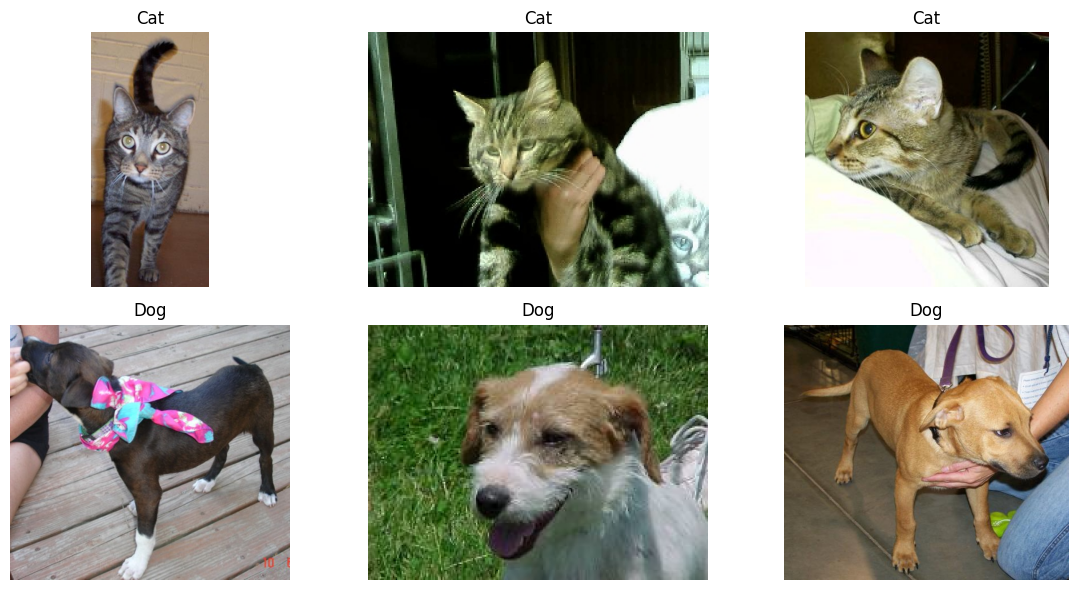

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select a few images
cat_files = cat_images[:3]
dog_files = dog_images[:3]

plt.figure(figsize=(12, 6))

# Display cats
for i, filename in enumerate(cat_files):
    img = Image.open(os.path.join(cat_path, filename))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

# Display dogs
for i, filename in enumerate(dog_files):
    img = Image.open(os.path.join(dog_path, filename))
    plt.subplot(2, 3, i + 4)
    plt.imshow(img)
    plt.title("Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split

In [17]:
IMG_SIZE = (64, 64)

HOG_ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)

print("Image size:", IMG_SIZE)
print("HOG orientations:", HOG_ORIENTATIONS)
print("Pixels per cell:", PIXELS_PER_CELL)
print("Cells per block:", CELLS_PER_BLOCK)

Image size: (64, 64)
HOG orientations: 9
Pixels per cell: (8, 8)
Cells per block: (2, 2)


In [18]:
def extract_hog_features(image_path):
    # Open image and convert to grayscale
    image = Image.open(image_path).convert("L")

    # Resize image to 64 × 64
    image = image.resize(IMG_SIZE)

    # Convert image to NumPy array
    image = np.array(image)

    # Extract HOG features
    features = hog(
        image,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=PIXELS_PER_CELL,
        cells_per_block=CELLS_PER_BLOCK,
        block_norm="L2-Hys"
    )

    return features

In [19]:
# Select one cat image
test_cat = os.path.join(cat_path, cat_images[0])

# Extract HOG features
cat_features = extract_hog_features(test_cat)

print("Feature vector shape:", cat_features.shape)
print("Number of features:", len(cat_features))

Feature vector shape: (1764,)
Number of features: 1764


In [20]:
# Select one dog image
test_dog = os.path.join(dog_path, dog_images[0])

# Extract HOG features
dog_features = extract_hog_features(test_dog)

print("Feature vector shape:", dog_features.shape)
print("Number of features:", len(dog_features))

Feature vector shape: (1764,)
Number of features: 1764


In [21]:
MAX_IMAGES_PER_CLASS = 4000

print("Cats to process:", MAX_IMAGES_PER_CLASS)
print("Dogs to process:", MAX_IMAGES_PER_CLASS)
print("Total images:", MAX_IMAGES_PER_CLASS * 2)

Cats to process: 4000
Dogs to process: 4000
Total images: 8000


In [22]:
X = []
y = []

print("Feature list created:", len(X))
print("Label list created:", len(y))

Feature list created: 0
Label list created: 0


In [23]:
from tqdm.auto import tqdm

# Process cat images
for filename in tqdm(cat_images[:MAX_IMAGES_PER_CLASS], desc="Processing Cats"):
    image_path = os.path.join(cat_path, filename)

    try:
        features = extract_hog_features(image_path)

        X.append(features)
        y.append(0)  # Cat = 0

    except Exception:
        continue


# Process dog images
for filename in tqdm(dog_images[:MAX_IMAGES_PER_CLASS], desc="Processing Dogs"):
    image_path = os.path.join(dog_path, filename)

    try:
        features = extract_hog_features(image_path)

        X.append(features)
        y.append(1)  # Dog = 1

    except Exception:
        continue


print("Total images processed:", len(X))
print("Total labels created:", len(y))

Processing Cats:   0%|          | 0/4000 [00:00<?, ?it/s]

Processing Dogs:   0%|          | 0/4000 [00:00<?, ?it/s]

Total images processed: 7999
Total labels created: 7999


In [24]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7999, 1764)
y shape: (7999,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])
print("Training features:", X_train.shape[1])

Training images: 6399
Testing images: 1600
Training features: 1764


In [26]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

print("SVM model created successfully.")

SVM model created successfully.


In [27]:
print("Starting SVM training...")

svm_model.fit(X_train, y_train)

print("SVM training completed!")

Starting SVM training...
SVM training completed!


In [28]:
print("Making predictions...")

y_pred = svm_model.predict(X_test)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Making predictions...
Predictions completed!
Number of predictions: 1600


In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 75.69%


In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Cat", "Dog"]
))

              precision    recall  f1-score   support

         Cat       0.75      0.76      0.76       800
         Dog       0.76      0.75      0.76       800

    accuracy                           0.76      1600
   macro avg       0.76      0.76      0.76      1600
weighted avg       0.76      0.76      0.76      1600



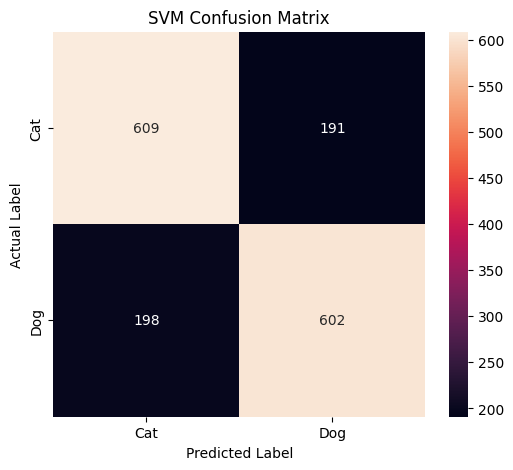

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()